<a href="https://colab.research.google.com/github/pachterlab/cellmender/blob/main/benchmarking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# try:
#     from cellsweep import denoise_count_matrix
# except ImportError:
#     print("cellsweep not found, installing...")
#     !pip install -U -q cellsweep[analysis]

In [2]:
import os
import sys
import numpy as np
import pandas as pd
import itertools
import yaml
import requests
import matplotlib.pyplot as plt
import anndata as ad
from collections import OrderedDict
import seaborn as sns
import scanpy as sc
from IPython.display import Image, display
# from cellbender.remove_background.downstream import anndata_from_h5
from cellsweep.constants import CellBender_Fig2_to_Immune_All_High_celltype_mapping, CellBender_Fig2_to_Immune_All_Low_celltype_mapping, CellTypistHigh_to_ImmuneMajor, CellTypistLow_to_ImmuneMajor
from cellsweep import denoise_count_matrix
from cellsweep.simulation import simulate_cells
import cellsweep.utils as cs_utils

cellsweep_dir = os.path.dirname(os.path.abspath(""))
rver_docker_workspace = "/home/ruser/work/cellsweep"

# import importlib
# import cellsweep.celltype_ambient
# importlib.reload(cellsweep.celltype_ambient)
# from cellsweep.celltype_ambient import denoise_count_matrix

# import importlib
# import cellsweep.utils.visualization_utils as visualization_utils
# importlib.reload(visualization_utils)
# importlib.reload(cs_utils)

# Compare CellBender vs. cellsweep

Some datasets of use:
- pbmc8k: 8k PBMCs from a healthy donor (CellBender Fig2): https://www.10xgenomics.com/datasets/8-k-pbm-cs-from-a-healthy-donor-2-standard-2-1-0
  - see run configuration on page 13 (bottom left) of the [Cellbender manuscript](https://doi.org/10.1038/s41592-023-01943-7)
- hgmm12k: Human-mouse mixture (CellBender Fig5): https://support.10xgenomics.com/single-cell-gene-expression/datasets/2.1.0/hgmm_12k

In [43]:
dataset_name = "hgmm12k"  # options: pbmc8k, hgmm12k, kidney_nuclei_10k, melanoma, pbmc_mouse_5k, pbmc_33k, simulation1_small_noise, simulation2_no_noise, simulation3_all_noise, custom  # for a custom dataset, make a new yaml file with the desired config - see example template at notebooks/config/custom.yaml
alternative_tools = ["cellbender", "soupx", "decontx", "scar"]  # ["cellbender", "soupx", "decontx", "scar"]
rerun_tools = False  # rerun tools if files don't exist OR if overwrite=True (else download from Box) - if True, requires docker
verbose = 2  # 2 debug, 1 info, 0 warning, -1 error, -2 critical
overwrite = False  # overwrite existing files
scar_env = "/home/jrich/miniconda3/envs/scar"
use_cuda = False  # for CellBender and scAR
threads = 8  # for cellsweep and CellBender (if use_cuda=False)
docker = "podman"  # "docker" or "podman" - if podman, then run `sudo setenforce 0` to disable SELinux enforcement before the podman commands

In [4]:
# load yaml
yaml_file = os.path.join(cellsweep_dir, "notebooks", "config", f"{dataset_name}.yaml")
cfg = cs_utils.load_dataset_yaml(yaml_file)

# create directories for data, output
data_dir = os.path.join(cellsweep_dir, "notebooks", "data", dataset_name)
os.makedirs(data_dir, exist_ok=True)

out_dir = os.path.join(cellsweep_dir, "notebooks", "output", dataset_name)
os.makedirs(out_dir, exist_ok=True)

# raw adata
if cfg.get("adata_raw_file_name") is None:
    if cfg.get("adata_raw_url") is not None:
        cfg["adata_raw_file_name"] = cfg["adata_raw_url"].split("/")[-1]
    # else:
    #     raise ValueError("If adata_raw_file_name is not specified in the config yaml, adata_raw_url must be specified.")

adata_path_raw = f"{data_dir}/{cfg['adata_raw_file_name']}" if cfg['adata_raw_file_name'] is not None else None
if adata_path_raw and not os.path.exists(adata_path_raw) and cfg["adata_raw_url"] is not None:
    !wget -O {adata_path_raw} {cfg["adata_raw_url"]}

# raw and filtered matrix tar files
matrix_tar_files_dir = os.path.join(data_dir, "matrix_tar_files")
os.makedirs(matrix_tar_files_dir, exist_ok=True)

raw_tar_file_dir = None
if len(os.listdir(matrix_tar_files_dir)) == 0 and cfg["raw_tar_url"] is not None and (rerun_tools or adata_path_raw is None):
    raw_tar_file_name = cfg["raw_tar_url"].split("/")[-1]
    raw_tar_path = os.path.join(matrix_tar_files_dir, raw_tar_file_name)
    !wget -O {raw_tar_path} {cfg["raw_tar_url"]}
    !tar -xvzf {raw_tar_path} -C {matrix_tar_files_dir}
    if cfg.get('raw_tar_file_dir_suffix') is None:
        raw_tar_file_dir = cs_utils.find_single_branch_leaf_dir(matrix_tar_files_dir)
    else:
        raw_tar_file_dir = f"{matrix_tar_files_dir}/{cfg['raw_tar_file_dir_suffix']}"

filtered_tar_file_dir = None
if len(os.listdir(matrix_tar_files_dir)) == 0 and cfg["filtered_tar_url"] is not None and rerun_tools:
    filtered_tar_file_name = cfg["filtered_tar_url"].split("/")[-1]
    filtered_tar_path = os.path.join(matrix_tar_files_dir, filtered_tar_file_name)
    !wget -O {filtered_tar_path} {cfg["filtered_tar_url"]}
    !tar -xvzf {filtered_tar_path} -C {matrix_tar_files_dir}
    if cfg.get('filtered_tar_file_dir_suffix') is None:
        filtered_tar_file_dir = cs_utils.find_single_branch_leaf_dir(matrix_tar_files_dir)
    else:
        filtered_tar_file_dir = f"{matrix_tar_files_dir}/{cfg['filtered_tar_file_dir_suffix']}"

sequencing_technology = cfg["sequencing_technology"]

# set file paths for tools
adata_path_cellsweep = f"{data_dir}/{cfg['adata_path_cellsweep_name']}"
cellsweep_log_file = os.path.join(data_dir, "cellsweep.log")

adata_path_cellbender = f"{data_dir}/{cfg['adata_path_cellbender_name']}"
adata_path_cellbender_filtered = adata_path_cellbender.replace(".h5", "_filtered.h5")
cellbender_ckpt = os.path.join(data_dir, "cellbender_ckpt.tar.gz")

soupx_out_prefix = f"{data_dir}/{cfg['soupx_out_prefix_name']}"
adata_soupx_obs_csv = f"{data_dir}/{dataset_name}_soupx_obs.csv"

decontx_out_prefix = f"{data_dir}/{cfg['decontx_out_prefix_name']}"

adata_path_scar = f"{data_dir}/{cfg['adata_path_scar_name']}"


if dataset_name == "hgmm12k":    
    matrix_tar_files_dir = os.path.join(matrix_tar_files_dir, "combined")
    raw_tar_file_dir = os.path.join(matrix_tar_files_dir, "raw_gene_bc_matrices", "combined")
    filtered_tar_file_dir = os.path.join(matrix_tar_files_dir, "filtered_gene_bc_matrices", "combined")
    # # check if raw_tar_file_dir is empty or doesn't exist
    # if rerun_tools and (not os.path.exists(raw_tar_file_dir) or len(os.listdir(raw_tar_file_dir)) == 0) or (not os.path.exists(filtered_tar_file_dir) or len(os.listdir(filtered_tar_file_dir)) == 0):
    adata_raw = cs_utils.load_adata(adata_path_raw, verbose=verbose)
    umi_cutoff = cs_utils.knee_plot(adata_raw, expected_cells=cfg["expected_cells"], show=False)
    adata_raw = cs_utils.infer_empty_droplets(adata_raw, method="threshold", umi_cutoff=umi_cutoff, verbose=verbose)  # adds adata.obs["is_empty"]
    paths = cs_utils.write_10x_like(adata_raw, matrix_tar_files_dir, gzip_output=(True if sequencing_technology == "10XV3" else False), is_empty_col="is_empty", cluster_col=None, genome="combined", write_raw=True, write_filtered=True)
    
    # # soupx inputs
    # matrix_tar_files_dir
    adata_soupx_obs_csv = paths["clusters"]
    # soupx_out_prefix

    # # decontx inputs
    raw_tar_file_dir = paths["raw"]
    filtered_tar_file_dir = paths["filtered"]
    sequencing_technology = paths["technology"]
    # decontx_out_prefix

if dataset_name.startswith("simulation"):
    # simulate data
    if not os.path.exists(adata_path_raw) or overwrite:
        adata_raw = simulate_cells(
            G=cfg["G"],
            k=cfg["k"],
            markers_per_type=cfg["markers_per_type"],
            marker_boost=cfg["marker_boost"],
            type_proportions=cfg["type_proportions"],
            empty_prob=cfg["empty_prob"],
            alpha=cfg["alpha"],
            beta=cfg["beta"],
            expected_cell_size=cfg["expected_cell_size"],
            rng_seed=42,
        )
        adata_raw.write_h5ad(adata_path_raw)
    else:
        adata_raw = cs_utils.load_adata(adata_path_raw, verbose=verbose)

    paths = cs_utils.write_10x_like(adata_raw, matrix_tar_files_dir, gzip_output=(True if sequencing_technology == "10XV3" else False), is_empty_col="is_empty", cluster_col=None, write_raw=True, write_filtered=True)

    # # soupx inputs
    # matrix_tar_files_dir
    adata_soupx_obs_csv = paths["clusters"]
    # soupx_out_prefix

    # # decontx inputs
    raw_tar_file_dir = paths["raw"]
    filtered_tar_file_dir = paths["filtered"]
    sequencing_technology = paths["technology"]
    # decontx_out_prefix


# lay out parameters
model_pkl = cfg["model_pkl"]
celltypist_convert = cfg["celltypist_convert"]
celltypist_map_file = cfg["celltypist_map_file"]
cellsweep_max_iter = cfg["cellsweep_max_iter"]
cellsweep_beta = cfg["cellsweep_beta"]
cellsweep_init_alpha = cfg["cellsweep_init_alpha"]
cellbender_epochs = cfg["cellbender_epochs"]
cellbender_fpr = cfg["cellbender_fpr"]
cellbender_zdim = cfg["cellbender_zdim"]
cellbender_expected_cells = cfg["cellbender_expected_cells"]
cellbender_total_droplets = cfg["cellbender_total_droplets"]
scar_epochs = cfg["scar_epochs"]
scar_prob = cfg["scar_prob"]
expected_cells = cfg["expected_cells"]
min_genes = cfg["min_genes"]
min_cells = cfg["min_cells"]
umi_top_percentile_to_remove = cfg["umi_top_percentile_to_remove"]
fraction_doublet = cfg["fraction_doublet"]
unique_genes_top_percentile_to_remove = cfg["unique_genes_top_percentile_to_remove"]
mt_gene_percentile_to_remove = cfg["mt_gene_percentile_to_remove"]
max_mt_percentage = cfg["max_mt_percentage"]
n_top_genes = cfg["n_top_genes"]
n_pcs = cfg["n_pcs"]
n_neighbors = cfg["n_neighbors"]
leiden_resolution = cfg["leiden_resolution"]
marker_genes = cfg["marker_genes"]

cellsweep_matrix_url = cfg["cellsweep_matrix_url"]
cellbender_matrix_filtered_url = cfg["cellbender_matrix_filtered_url"]
cellbender_ckpt_url = cfg["cellbender_ckpt_url"]
soupx_matrix_url = cfg["soupx_matrix_url"]
decontx_matrix_url = cfg["decontx_matrix_url"]
scar_matrix_url = cfg["scar_matrix_url"]

16:15:09 - INFO - Loading adata from '/home/jrich/Desktop/cellsweep/notebooks/data/hgmm12k/hgmm_12k_raw_gene_bc_matrices_h5.h5'
16:15:09 - INFO - Multiple genomes found in '/home/jrich/Desktop/cellsweep/notebooks/data/hgmm12k/hgmm_12k_raw_gene_bc_matrices_h5.h5': ['hg19', 'mm10']. Loading each separately.
16:15:09 - INFO - Loading genome 'hg19' from '/home/jrich/Desktop/cellsweep/notebooks/data/hgmm12k/hgmm_12k_raw_gene_bc_matrices_h5.h5'
/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
16:15:11 - INFO - Loading genome 'mm10' from '/home/jrich/Desktop/cellsweep/notebooks/data/hgmm12k/hgmm_12k_raw_gene_bc_matrices_h5.h5'
/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_uniqu

UMI cutoff for expected cells (12820): 3084.00
Found existing 10x files in '/home/jrich/Desktop/cellsweep/notebooks/data/hgmm12k/matrix_tar_files/combined/raw_gene_bc_matrices/combined'. Skipping write.
Found existing 10x files in '/home/jrich/Desktop/cellsweep/notebooks/data/hgmm12k/matrix_tar_files/combined/filtered_gene_bc_matrices/combined'. Skipping write.


## Raw

In [5]:
if adata_path_raw is not None and os.path.exists(adata_path_raw):
    adata_raw = cs_utils.load_adata(adata_path_raw, verbose=verbose)
elif raw_tar_file_dir is not None and os.path.exists(raw_tar_file_dir):
    adata_raw = cs_utils.load_adata(raw_tar_file_dir, verbose=verbose)
else:
    raise ValueError("No raw data found.")
adata_raw.var_names_make_unique()

16:15:25 - INFO - Loading adata from '/home/jrich/Desktop/cellsweep/notebooks/data/hgmm12k/hgmm_12k_raw_gene_bc_matrices_h5.h5'
16:15:25 - INFO - Multiple genomes found in '/home/jrich/Desktop/cellsweep/notebooks/data/hgmm12k/hgmm_12k_raw_gene_bc_matrices_h5.h5': ['hg19', 'mm10']. Loading each separately.
16:15:25 - INFO - Loading genome 'hg19' from '/home/jrich/Desktop/cellsweep/notebooks/data/hgmm12k/hgmm_12k_raw_gene_bc_matrices_h5.h5'
/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
16:15:27 - INFO - Loading genome 'mm10' from '/home/jrich/Desktop/cellsweep/notebooks/data/hgmm12k/hgmm_12k_raw_gene_bc_matrices_h5.h5'
/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_uniqu

## Knee plot - use this output to estimate umi_cutoff

UMI cutoff for expected cells (12820): 3084.00


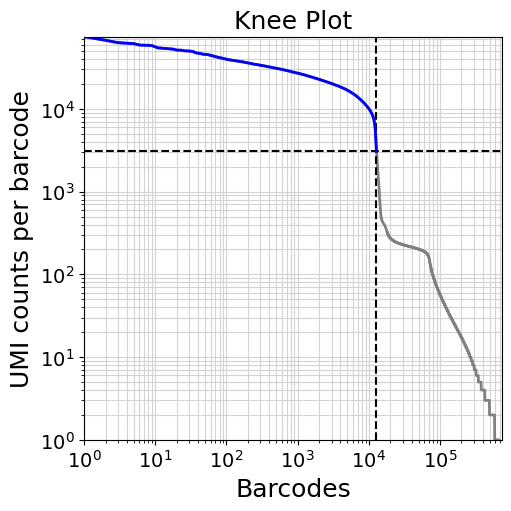

In [6]:
umi_cutoff = cs_utils.knee_plot(adata_raw, expected_cells=expected_cells, out_path=os.path.join(out_dir, "knee_plot.png"))

In [7]:
# umi_cutoff = 0  #!!! optionally update from knee plot
adata_raw = cs_utils.infer_empty_droplets(adata_raw, method="threshold", umi_cutoff=umi_cutoff, verbose=verbose)  # adds adata.obs["is_empty"]
adata_raw.var['empty_counts'] = np.array(adata_raw.X[adata_raw.obs['is_empty'].values, :].sum(axis=0)).flatten()

In [8]:
if dataset_name == "hgmm12k" and 'celltype' not in adata_raw.obs:
    adata_raw.obs['hg19_total_counts'] = np.asarray(adata_raw[:, adata_raw.var['genome'] == 'hg19'].X.sum(axis=1)).ravel()
    adata_raw.obs['mm10_total_counts'] = np.asarray(adata_raw[:, adata_raw.var['genome'] == 'mm10'].X.sum(axis=1)).ravel()
    adata_raw.obs['genome'] = np.where(adata_raw.obs['hg19_total_counts'] >= adata_raw.obs['mm10_total_counts'], 'hg19', 'mm10')  # predict genome
    adata_raw.obs['celltype'] = adata_raw.obs['genome']

    adata_raw = cs_utils.detect_doublets_human_mouse(adata_raw, fraction_doublet=fraction_doublet, plot_empty=False, umi_cutoff=umi_cutoff, expected_cells=expected_cells, out_path=os.path.join(out_dir, "hgmm12k_doublet_detection.png"), show=False)

hg19_RPS2: 288402.0
hg19_RPL10: 153516.0
hg19_RPS18: 152179.0
hg19_RPS4X: 145981.0
hg19_RPS6: 125242.0
hg19_RPL13: 115657.0
hg19_RPS19: 111334.0
hg19_RPS14: 111253.0
hg19_RPL15: 110307.0
hg19_RPLP1: 108770.0


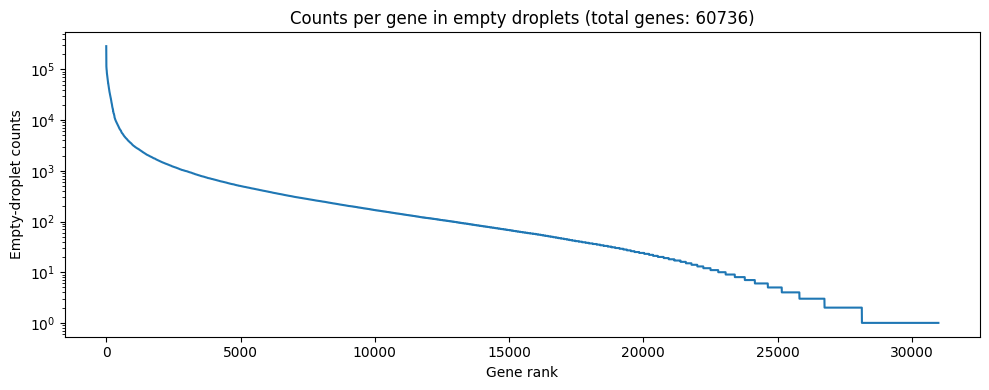

In [9]:
cs_utils.plot_empty_gene_counts(adata_raw, out_path=os.path.join(out_dir, "empty_droplet_gene_counts.png"))
cs_utils.print_top_empty_genes(adata_raw, top_n=10, out_path=os.path.join(out_dir, "empty_genes.csv"))

## cellsweep

In [10]:
%%time
if not os.path.exists(adata_path_cellsweep) or overwrite:
    adata = adata_raw.copy()
    if "celltype" not in adata.obs.columns:
        adata = cs_utils.determine_cell_types(adata, model_pkl=model_pkl, filter_empty=True, expected_cells=expected_cells, celltypist_convert=celltypist_convert, celltypist_map_file=celltypist_map_file, verbose=verbose)
    _ = denoise_count_matrix(adata, adata_out=adata_path_cellsweep, beta=cellsweep_beta, freeze_ambient_profile=True, init_alpha=cellsweep_init_alpha, max_iter=cellsweep_max_iter, empty_droplet_method="threshold", expected_cells=expected_cells, threads=threads, verbose=verbose, log_file=cellsweep_log_file)

CPU times: user 0 ns, sys: 214 μs, total: 214 μs
Wall time: 165 μs


In [11]:
adata_cellsweep = ad.read_h5ad(adata_path_cellsweep)
adata_cellsweep = adata_cellsweep[~adata_cellsweep.obs["is_empty"]].copy()
adata_cellsweep.var_names_make_unique()
print(f"Counts are less than or equal check for cellsweep: {cs_utils.check_counts_less_equal(adata_raw, adata_cellsweep)}")

Counts are less than or equal check for cellsweep: True


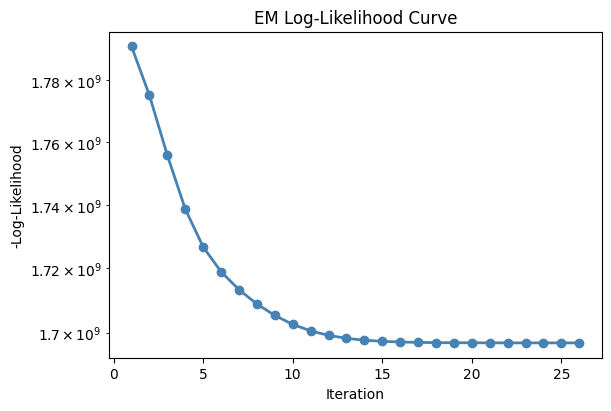

UMI cutoff for expected cells (12820): 3084.00
UMI cutoff for expected cells (12820): 3084.00


,is_empty,hg19_total_counts,mm10_total_counts,genome,celltype,is_doublet,cell_ambient_fraction,alpha_hat,z_hat,total_counts_raw,total_counts_denoised
AAACCTGAGAACAATC-1,False,300.0,9904.0,mm10,mm10,False,0.9,0.037730,2,10204.0,9742.128001
AAACCTGAGCATCATC-1,False,132.0,3930.0,mm10,mm10,False,0.9,0.042736,2,4062.0,3858.106184
AAACCTGAGCCCTAAT-1,False,17946.0,195.0,hg19,hg19,False,0.9,0.023555,1,18141.0,17575.185208
AAACCTGAGCGGATCA-1,False,6931.0,71.0,hg19,hg19,False,0.9,0.021852,1,7002.0,6796.086946
AAACCTGAGCGTGAAC-1,False,402.0,16034.0,mm10,mm10,False,0.9,0.029763,2,16436.0,15821.346464
AAACCTGAGGGAGTAA-1,False,523.0,22668.0,mm10,mm10,False,0.9,0.026862,2,23191.0,22390.587794
AAACCTGAGGGCTTCC-1,False,15550.0,177.0,hg19,hg19,False,0.9,0.024687,1,15727.0,15219.504688
AAACCTGAGTCCGGTC-1,False,352.0,14695.0,mm10,mm10,False,0.9,0.028131,2,15047.0,14508.307242
AAACCTGAGTCTCCTC-1,False,290.0,12711.0,mm10,mm10,False,0.9,0.025489,2,13001.0,12568.228877
AAACCTGCACAGATTC-1,False,36154.0,286.0,hg19,hg19,False,0.9,0.015071,1,36440.0,35613.009088


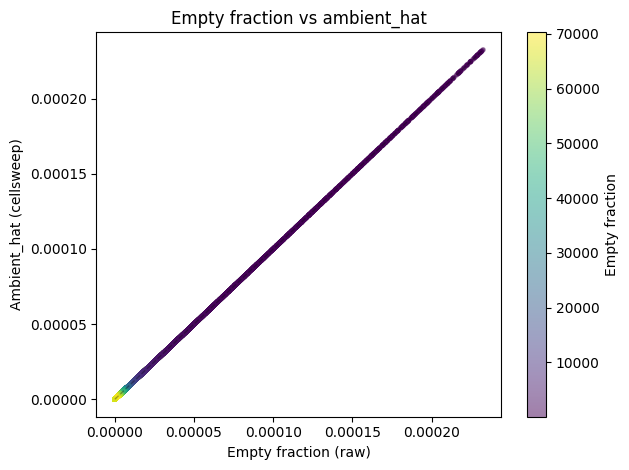

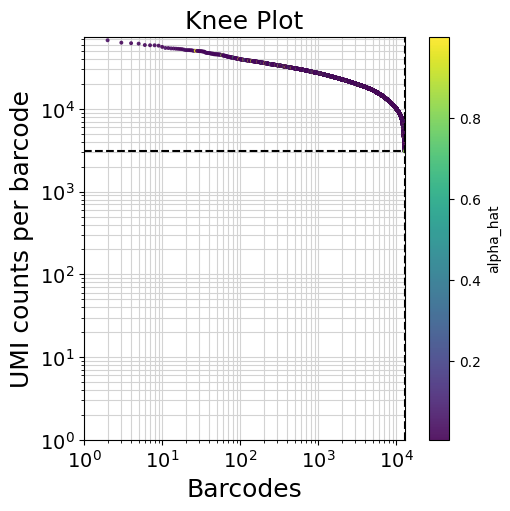

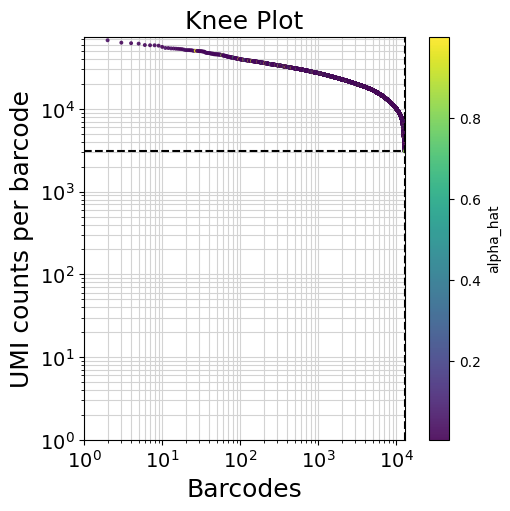

In [12]:
# plot cellsweep likelihood over epochs
if os.path.exists(cellsweep_log_file):
    cs_utils.plot_cellsweep_likelihood_over_epochs(log_path=cellsweep_log_file, show=True)

# plot ambient_hat vs empty fraction
cs_utils.plot_ambient_hat_vs_empty_fraction(adata_raw, adata_cellsweep, remove_zeroes=True, lower_quantile_removed=None, upper_quantile_removed=0.99, out_path=os.path.join(out_dir, "cellsweep_ambient_hat_vs_empty_fraction.png"))

# plot knee plot colored by alpha_hat
adata_denoised = adata_cellsweep.copy()
adata_denoised.layers["denoised"] = adata_denoised.X.copy()
adata_denoised.X = adata_denoised.layers["raw"].copy()
cs_utils.knee_plot(adata_denoised, expected_cells=expected_cells, color_column="alpha_hat")
cs_utils.knee_plot(adata_denoised[~adata_denoised.obs["is_empty"]], expected_cells=expected_cells, color_column="alpha_hat")
adata_denoised.obs["total_counts_raw"] = np.ravel(adata_denoised.layers["raw"].sum(axis=1))
adata_denoised.obs["total_counts_denoised"] = np.ravel(adata_denoised.layers["denoised"].sum(axis=1))
adata_denoised.obs.loc[~adata_denoised.obs["is_empty"]].head(50)

## CellBender (v0.3.0)

In [44]:
%%time
if "cellbender" in alternative_tools and (not os.path.exists(adata_path_cellbender_filtered) or overwrite):
     if rerun_tools or cellbender_matrix_filtered_url is None:
          runtime = "--cuda" if use_cuda else f"--cpu-threads {threads}"
          expected_cells_line = f"--expected-cells {cellbender_expected_cells}" if cellbender_expected_cells is not None else ""
          total_droplets_line = f"--total-droplets-included {cellbender_total_droplets}" if cellbender_total_droplets is not None else ""
          gpus = "--gpus all" if use_cuda else ""
          input_path = adata_path_raw.replace(f"{cellsweep_dir}/notebooks/data", "/data")
          output_dir = os.path.dirname(adata_path_cellbender).replace(f"{cellsweep_dir}/notebooks/data", "/data")
          output_path = adata_path_cellbender.replace(f"{cellsweep_dir}/notebooks/data", "/data")
          ckpt_out_path = cellbender_ckpt.replace(f"{cellsweep_dir}/notebooks/data", "/data")
          # note that if I echo this, then I need to add extra quotes around the bash -c command to copy-paste it
          !{docker} run --rm {gpus} -v {cellsweep_dir}/notebooks/data:/data us.gcr.io/broad-dsde-methods/cellbender:0.3.0 \
               bash -c 'mkdir -p {output_dir} && cellbender remove-background \
               --input {input_path} {expected_cells_line} {total_droplets_line} \
               --output {output_path} \
               --epochs {cellbender_epochs} \
               --fpr {cellbender_fpr} \
               --z-dim {cellbender_zdim} \
               --model full \
               {runtime} && \
               mv ckpt.tar.gz {ckpt_out_path}'
     else:
          !wget -O {adata_path_cellbender_filtered} {cellbender_matrix_filtered_url}
          !wget -O {cellbender_ckpt} {cellbender_ckpt_url}

CPU times: user 43 μs, sys: 0 ns, total: 43 μs
Wall time: 52.2 μs


In [45]:
adata_cellbender = None
if "cellbender" in alternative_tools:
    adata_cellbender = sc.read_10x_h5(adata_path_cellbender_filtered, gex_only=False)
    adata_cellbender.var_names_make_unique()
    print(f"Counts are less than or equal check for CellBender: {cs_utils.check_counts_less_equal(adata_raw, adata_cellbender)}")

/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Counts are less than or equal check for CellBender: True


## SoupX (v1.6.2)

In [46]:
%%time
if "soupx" in alternative_tools and (soupx_out_prefix and (not os.path.exists(f"{soupx_out_prefix}.mtx") or overwrite)):
    if rerun_tools or soupx_matrix_url is None:
        if not os.path.exists(adata_soupx_obs_csv) or overwrite:
            adata_soupx_tmp = cs_utils.load_adata(filtered_tar_file_dir)
            adata_soupx_tmp = cs_utils.run_scanpy_preprocessing_and_clustering(adata_soupx_tmp, min_genes=min_genes, min_cells=min_cells, max_mt_percentage=max_mt_percentage, n_top_genes=n_top_genes, n_pcs=n_pcs, n_neighbors=n_neighbors, leiden_resolution=leiden_resolution, seed=42, verbose=verbose)
            adata_soupx_tmp.obs[["leiden"]].to_csv(adata_soupx_obs_csv)

        !{docker} run --rm \
            -w /home/ruser/work \
            -v {cellsweep_dir}:{rver_docker_workspace} \
            josephrich98/cellsweep_tutorials:soupx.0.1.0 \
            Rscript {rver_docker_workspace}/scripts/run_soupx.R \
                {matrix_tar_files_dir.replace(cellsweep_dir, rver_docker_workspace)} \
                {adata_soupx_obs_csv.replace(cellsweep_dir, rver_docker_workspace)} \
                {soupx_out_prefix.replace(cellsweep_dir, rver_docker_workspace)} \
                leiden
    else:
        !wget -O {soupx_out_prefix}.tar.gz {soupx_matrix_url}
        !tar -xvzf {soupx_out_prefix}.tar.gz -C {os.path.dirname(soupx_out_prefix)}

CPU times: user 39 μs, sys: 4 μs, total: 43 μs
Wall time: 52.2 μs


In [47]:
adata_soupx = None
if "soupx" in alternative_tools:
    adata_soupx = cs_utils.load_adata(soupx_out_prefix)
    adata_soupx.var_names_make_unique()
    print(f"Counts are less than or equal check for SoupX: {cs_utils.check_counts_less_equal(adata_raw, adata_soupx)}")

Counts are less than or equal check for SoupX: True


## DecontX (v1.8.0)

In [48]:
%%time
if "decontx" in alternative_tools and (decontx_out_prefix and (not os.path.exists(f"{decontx_out_prefix}.mtx") or overwrite)):
    if rerun_tools or decontx_matrix_url is None:
        !{docker} run --rm \
            -w /home/ruser/work \
            -v {cellsweep_dir}:{rver_docker_workspace} \
            josephrich98/cellsweep_tutorials:decontx.0.1.0 \
            Rscript {rver_docker_workspace}/scripts/run_decontx.R \
                {raw_tar_file_dir.replace(cellsweep_dir, rver_docker_workspace)} \
                {filtered_tar_file_dir.replace(cellsweep_dir, rver_docker_workspace)} \
                {cfg["sequencing_technology"]} \
                {decontx_out_prefix.replace(cellsweep_dir, rver_docker_workspace)} \
                --dont_prepend_sample_to_barcodes
    else:
        !wget -O {decontx_out_prefix}.tar.gz {decontx_matrix_url}
        !tar -xvzf {decontx_out_prefix}.tar.gz -C {os.path.dirname(decontx_out_prefix)}

CPU times: user 39 μs, sys: 5 μs, total: 44 μs
Wall time: 53.2 μs


In [49]:
adata_decontx = None
if "decontx" in alternative_tools:
    adata_decontx = cs_utils.load_adata(decontx_out_prefix)
    adata_decontx.obs_names = [name.replace("GRCh38_", "", 1) for name in adata_decontx.obs_names]
    adata_decontx.var_names_make_unique()
    print(f"Counts are less than or equal check for DecontX: {cs_utils.check_counts_less_equal(adata_raw, adata_decontx)}")

Counts are less than or equal check for DecontX: True


## scAR (v0.7.0)

In [50]:
%%time
%env MPLBACKEND=
if "scar" in alternative_tools and (adata_path_scar and (not os.path.exists(adata_path_scar) or overwrite)):
     if rerun_tools or scar_matrix_url is None:
          runtime = "--cuda" if use_cuda else ""
          conda_run_flag = "-p" if "/" in scar_env else "-n"
          !conda run {conda_run_flag} {scar_env} \
            python {cellsweep_dir}/scripts/run_scar.py \
            -r {raw_tar_file_dir} \
            -f {filtered_tar_file_dir} \
            -o {adata_path_scar} \
            -p {scar_prob} \
            {runtime} \
            --epochs {scar_epochs}
     else:
          !wget -O {adata_path_scar} {scar_matrix_url}

env: MPLBACKEND=
CPU times: user 1 ms, sys: 0 ns, total: 1 ms
Wall time: 886 μs


In [51]:
adata_scar = None
if "scar" in alternative_tools:
    adata_scar = ad.read_h5ad(adata_path_scar)
    adata_scar.var_names_make_unique()
    print(f"Counts are less than or equal check for scAR: {cs_utils.check_counts_less_equal(adata_raw, adata_scar)}")

Counts are less than or equal check for scAR: False


# Analysis

In [52]:
adata_dict = OrderedDict(
    raw=adata_raw,
    cellsweep=adata_cellsweep,
    cellbender=adata_cellbender,
    soupx=adata_soupx,
    decontx=adata_decontx,
    scar=adata_scar
)

for key, adata in adata_dict.items():
    if adata is None:
        continue
    print(f"{key}:\n{adata}\n\n")

raw:
AnnData object with n_obs × n_vars = 737280 × 60736
    obs: 'is_empty', 'hg19_total_counts', 'mm10_total_counts', 'genome', 'celltype', 'is_doublet', 'human_counts_total', 'mouse_counts_total'
    var: 'gene_ids', 'genome', 'empty_counts', 'empty_fraction'


cellsweep:
AnnData object with n_obs × n_vars = 12820 × 60736
    obs: 'is_empty', 'hg19_total_counts', 'mm10_total_counts', 'genome', 'celltype', 'is_doublet', 'cell_ambient_fraction', 'alpha_hat', 'z_hat', 'human_counts_total', 'mouse_counts_total'
    var: 'gene_ids', 'genome', 'empty_counts', 'ambient', 'ambient_hat'
    uns: 'beta_hat', 'celltype_names', 'celltype_profile', 'celltype_profile_genes', 'loglike', 'p_hat'
    layers: 'raw'


cellbender:
AnnData object with n_obs × n_vars = 14146 × 60736
    var: 'gene_ids', 'feature_types', 'genome'


soupx:
AnnData object with n_obs × n_vars = 12820 × 60736


decontx:
AnnData object with n_obs × n_vars = 12820 × 60736


scar:
AnnData object with n_obs × n_vars = 12820 × 607

## Simulations

In [53]:
if dataset_name.startswith("simulation"):
    for adata_name, adata in adata_dict.items():
        if adata_name == "raw" or adata is None:
            continue
            # adata = adata[~adata.obs['is_empty']].copy()
        cs_utils.evaluate_simulation_denoising(adata_processed = adata, adata_real = adata_dict["raw"], tool = adata_name, out_base = f"{out_dir}/{adata_name}_denoising_evaluation", show=True)

        adata_predicted_signal = adata.copy()
        adata_raw_tmp = adata_dict["raw"].copy()
        adata_predicted_signal, adata_raw_tmp = cs_utils.take_adata_cell_gene_intersection(adata_predicted_signal, adata_raw_tmp)

        adata_predicted_noise = adata_predicted_signal.copy()
        adata_predicted_noise.X = adata_raw_tmp.X - adata_predicted_signal.X  # noise = raw - signal
        
        adata_true_noise = adata_raw_tmp.copy()
        adata_true_noise.X = adata_raw_tmp.layers["noise"].copy()  # true noise

        adata_true_signal = adata_raw_tmp.copy()
        adata_true_signal.X = adata_raw_tmp.layers["real"].copy()

        show = (adata_name == "cellsweep")
        
        # noise plots
        cs_utils.plot_matrix_scatterplot(adata_predicted_noise, adata_true_noise, point_type="matrix", density_type="scatter_with_kde", scale="log", x_axis=f"{adata_name} predicted", y_axis="true", title=f"true vs {adata_name} predicted matrix noise Scatterplot", out_path=os.path.join(out_dir, f"true_vs_{adata_name}_predicted_noise_matrix_expression_scatterplot.png"), show=show)
        cs_utils.plot_matrix_scatterplot(adata_predicted_noise, adata_true_noise, point_type="cell", density_type="scatter_with_kde", scale="log", x_axis=f"{adata_name} predicted", y_axis="true", title=f"true vs {adata_name} predicted cell noise Scatterplot", out_path=os.path.join(out_dir, f"true_vs_{adata_name}_predicted_noise_cell_expression_scatterplot.png"), show=show)
        cs_utils.plot_matrix_scatterplot(adata_predicted_noise, adata_true_noise, point_type="gene", density_type="scatter_with_kde", scale="log", x_axis=f"{adata_name} predicted", y_axis="true", title=f"true vs {adata_name} predicted gene noise Scatterplot", out_path=os.path.join(out_dir, f"true_vs_{adata_name}_predicted_noise_gene_expression_scatterplot.png"), show=show)

        # signal plots - redundant with noise plots, so commented out
        # cs_utils.plot_matrix_scatterplot(adata_predicted_signal, adata_true_signal, point_type="matrix", density_type="scatter_with_kde", scale="log", x_axis=f"{adata_name} predicted", y_axis="true", title=f"true vs {adata_name} predicted matrix signal Scatterplot", out_path=os.path.join(out_dir, f"true_vs_{adata_name}_predicted_signal_matrix_expression_scatterplot.png"), show=show)
        # cs_utils.plot_matrix_scatterplot(adata_predicted_signal, adata_true_signal, point_type="cell", density_type="scatter_with_kde", scale="log", x_axis=f"{adata_name} predicted", y_axis="true", title=f"true vs {adata_name} predicted cell signal Scatterplot", out_path=os.path.join(out_dir, f"true_vs_{adata_name}_predicted_signal_cell_expression_scatterplot.png"), show=show)
        # cs_utils.plot_matrix_scatterplot(adata_predicted_signal, adata_true_signal, point_type="gene", density_type="scatter_with_kde", scale="log", x_axis=f"{adata_name} predicted", y_axis="true", title=f"true vs {adata_name} predicted gene signal Scatterplot", out_path=os.path.join(out_dir, f"true_vs_{adata_name}_predicted_signal_gene_expression_scatterplot.png"), show=show)

        del adata_raw_tmp
        del adata_predicted_signal
        del adata_predicted_noise
        del adata_true_signal
        del adata_true_noise

## UpSet plot of retained cells

/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  style

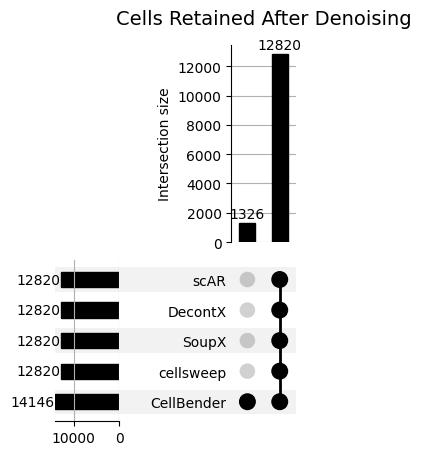

In [54]:
upset_data_dict = {
    # "Raw": set(adata_raw.obs_names),
    "cellsweep": set(adata_cellsweep.obs_names),
    "CellBender": set(adata_cellbender.obs_names) if adata_cellbender is not None else None,
    "SoupX": set(adata_soupx.obs_names) if adata_soupx is not None else None,
    "DecontX": set(adata_decontx.obs_names) if adata_decontx is not None else None,
    "scAR": set(adata_scar.obs_names) if adata_scar is not None else None
}

_ = cs_utils.make_upset_plot(upset_data_dict, title="Cells Retained After Denoising", out_path=os.path.join(out_dir, "cells_retained_upset.png"))

## Scatterplot of cell x gene expression differences

In [ ]:
adata_dict_nonempty_length = len([adata for adata in adata_dict.values() if adata is not None])
num_iterations = adata_dict_nonempty_length * (adata_dict_nonempty_length - 1) // 2  # n choose 2
iteration = 1
for (key1, val1), (key2, val2) in itertools.combinations(adata_dict.items(), 2):
    if val1 is None or val2 is None:
        continue
    
    print(f"{iteration}/{num_iterations} Comparing {key1} vs {key2}...")
    show = (key1 in {"raw", "cellsweep", "cellbender"} and key2 in {"raw", "cellsweep", "cellbender"})
    # Scatterplot by matrix, cell, and gene
    cs_utils.plot_matrix_scatterplot(val1, val2, point_type="matrix", density_type="scatter_with_density", scale="log", x_axis=key1, y_axis=key2, out_path=os.path.join(out_dir, f"{key2}_vs_{key1}_matrix_expression_scatterplot.png"), show=show)
    cs_utils.plot_matrix_scatterplot(val1, val2, point_type="cell", density_type="scatter_with_kde", scale="log", x_axis=key1, y_axis=key2, out_path=os.path.join(out_dir, f"{key2}_vs_{key1}_cell_expression_scatterplot.png"), show=show)
    cs_utils.plot_matrix_scatterplot(val1, val2, point_type="gene", density_type="scatter_with_kde", scale="log", x_axis=key1, y_axis=key2, out_path=os.path.join(out_dir, f"{key2}_vs_{key1}_gene_expression_scatterplot.png"), show=show)
    
    # Histogram of differences from raw by matrix, cell, and gene
    # cs_utils.plot_per_cell_difference(val1, val2, plot_type="matrix", tool_raw=key1, tool_processed=key2, out_path=os.path.join(out_dir, f"{key2}_per_matrix_absolute_difference_from_{key1}.png"))
    cs_utils.plot_per_cell_difference(val1, val2, plot_type="cell", tool_raw=key1, tool_processed=key2, out_path=os.path.join(out_dir, f"{key2}_per_cell_absolute_difference_from_{key1}.png"), show=show)
    cs_utils.plot_per_cell_difference(val1, val2, plot_type="gene", tool_raw=key1, tool_processed=key2, out_path=os.path.join(out_dir, f"{key2}_per_gene_absolute_difference_from_{key1}.png"), show=show)

    # Histogram of cosine similarity by cell and gene
    cs_utils.plot_per_cell_correlation(val1, val2, plot_type="cell", title=f"Per-Cell Cosine Similarity Histogram: {key1} vs {key2}", out_path=os.path.join(out_dir, f"{key2}_vs_{key1}_per_cell_correlation.png"), show=show)
    cs_utils.plot_per_cell_correlation(val1, val2, plot_type="gene", title=f"Per-Gene Cosine Similarity Histogram: {key1} vs {key2}", out_path=os.path.join(out_dir, f"{key2}_vs_{key1}_per_gene_correlation.png"), show=show)
    
    iteration += 1

In [ ]:
if dataset_name.startswith("simulation"):
    sys.exit()

## Joint scatterplot of human vs. mouse counts (hgmm12k dataset only)

raw human cell mouse gene contamination AUC: 3433952.6941070557
raw mouse cell human gene contamination AUC: 19332043.67050171


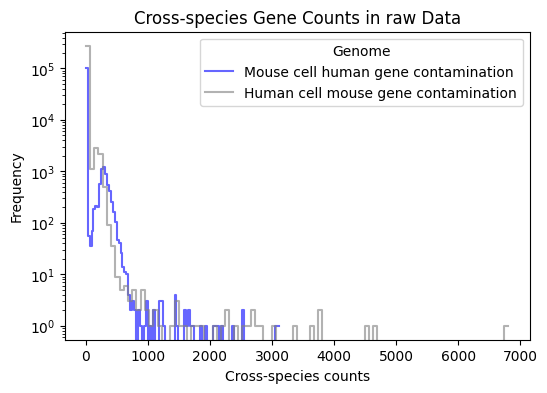

cellsweep human cell mouse gene contamination AUC: 701.3387318913453
cellsweep mouse cell human gene contamination AUC: 1070.337337194866


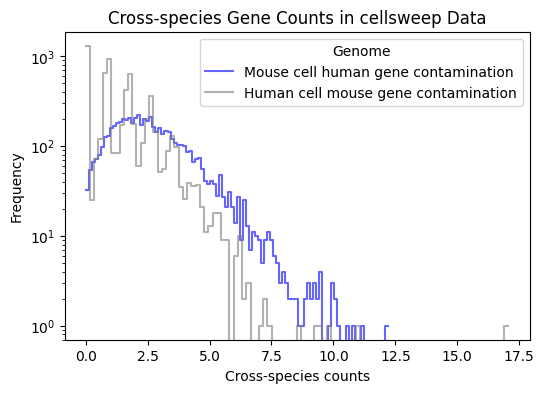

cellbender human cell mouse gene contamination AUC: 136480.39999999997
cellbender mouse cell human gene contamination AUC: 456481.7399999999


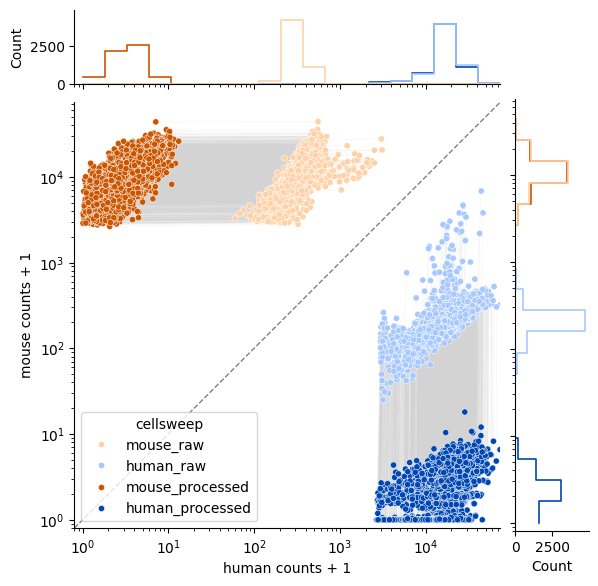

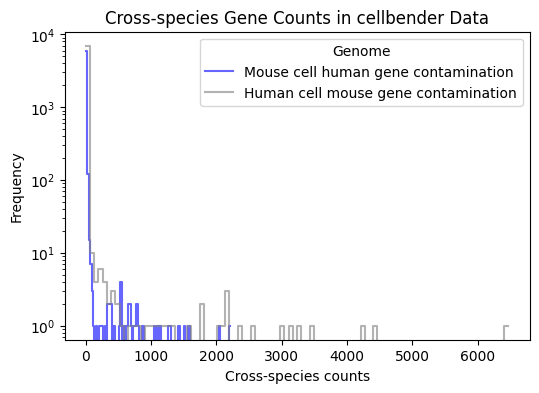

soupx human cell mouse gene contamination AUC: 159154.52885133974
soupx mouse cell human gene contamination AUC: 392445.66104046814


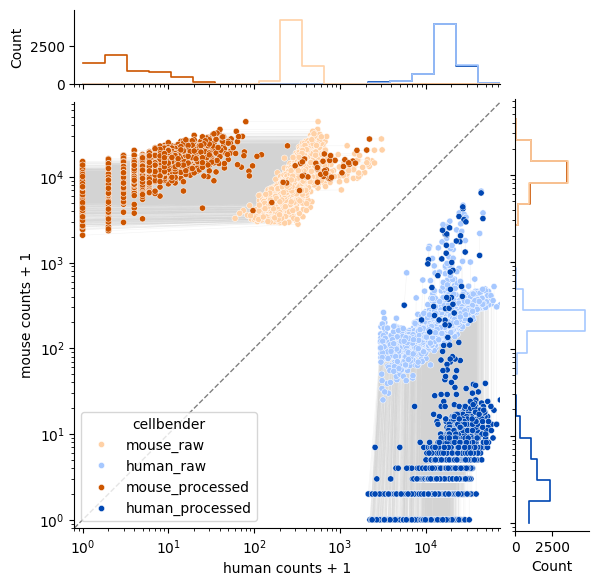

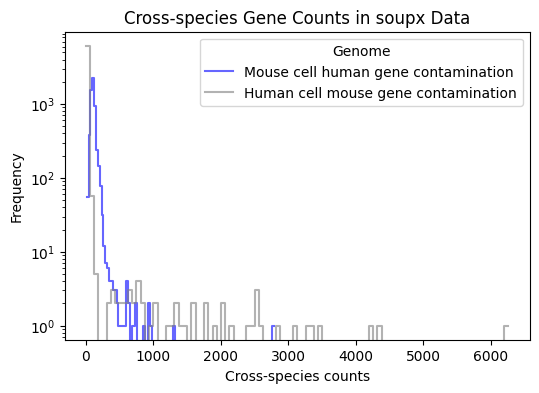

decontx human cell mouse gene contamination AUC: 154694.48030655144
decontx mouse cell human gene contamination AUC: 11136.646347481092


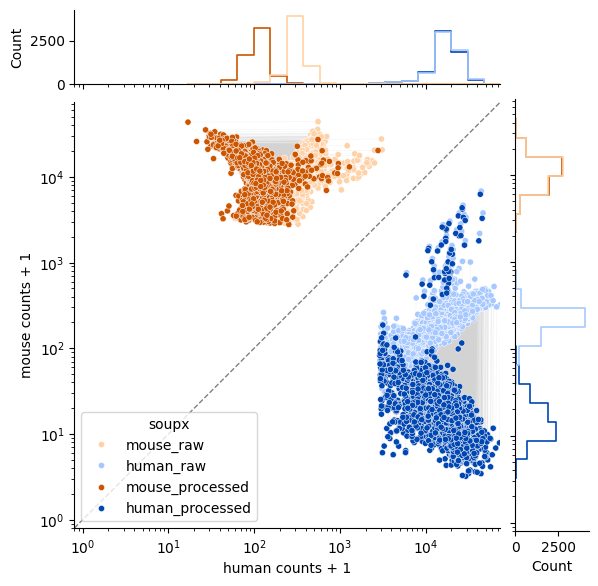

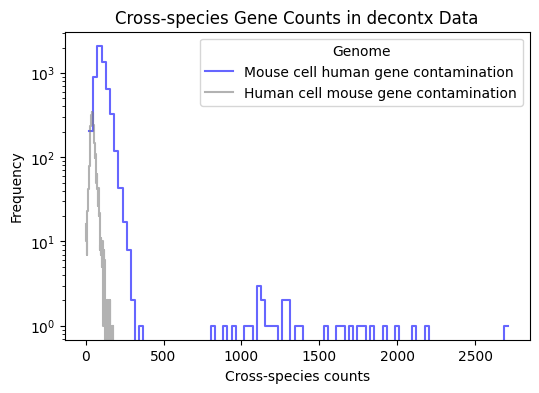

scar human cell mouse gene contamination AUC: 83604.30000000002
scar mouse cell human gene contamination AUC: 110136.31999999999


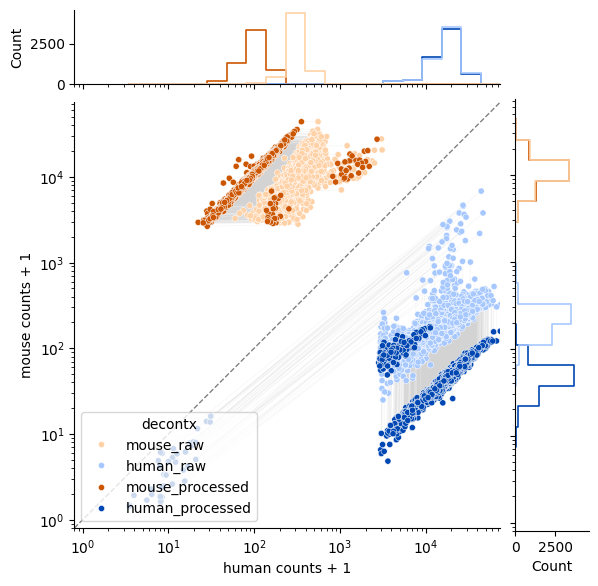

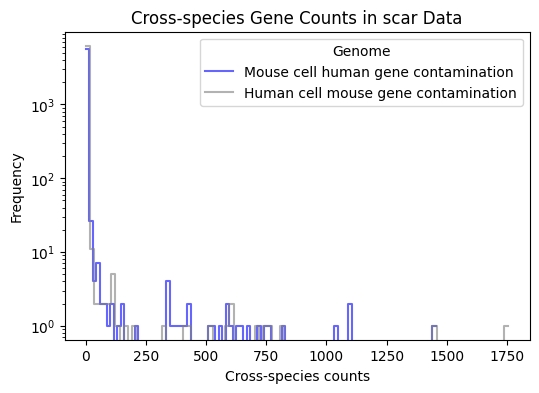

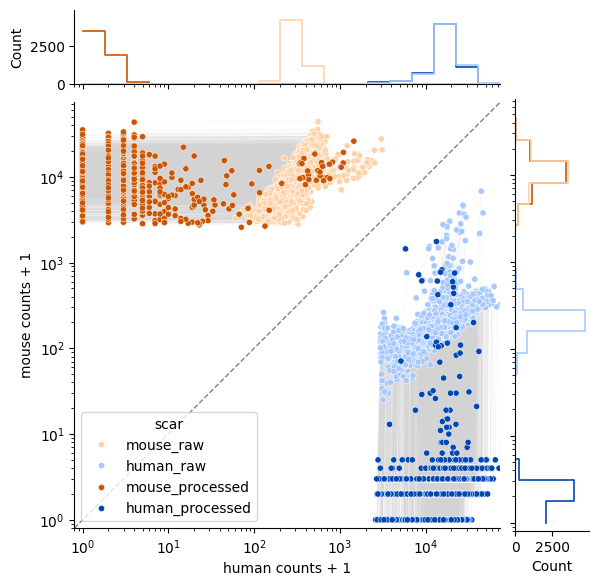

In [56]:
if dataset_name == "hgmm12k":
    cell_sets = [
        set(adata.obs_names)
        for key, adata in adata_dict.items()
        if adata is not None and key != "raw"
    ]
    cells_common_to_all_tools = set.intersection(*cell_sets)
    
    if "genome" not in adata_raw.obs.columns:
        adata_raw = cs_utils.identify_human_and_mouse_cells(adata_raw)
    
    doublet_cell_set = set(adata_raw.obs.index[adata_raw.obs["is_doublet"]])
    adata_raw_no_doublets = adata_raw[~adata_raw.obs["is_doublet"]].copy()        
    
    for key, adata_processed in adata_dict.items():
        if adata_processed is None:
            continue

        # add genome info to processed adata from raw
        if "genome" not in adata_processed.obs.columns:
            adata_processed.obs["genome"] = adata_raw.obs["genome"].reindex(adata_processed.obs_names)
            adata_dict[key] = adata_processed

        # plot histograms of human and mouse contamination
        cs_utils.plot_cross_species_histogram(adata_processed, processed_name=key, doublet_cell_set=doublet_cell_set, out_path=os.path.join(out_dir, f"{key}_human_mouse_contamination_histograms.png"))
        
        # plot joint scatterplots
        if key == "raw":
            continue
        adata_processed = adata_processed[adata_processed.obs_names.isin(cells_common_to_all_tools)].copy()
        cs_utils.plot_cross_species_joint_scatterplot(adata_raw_no_doublets, adata_processed, processed_name=key, marginal_type="histogram", fill_histogram=False, show_marginal_ticks=True, show_point_movement=True, out_path=os.path.join(out_dir, f"{key}_joint_scatterplot.png"), show=True)

In [ ]:
if dataset_name == "hgmm12k":
    sys.exit()

SystemExit: 

/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3587: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


## Alluvial plot of cluster differences

In [ ]:
adata_cellsweep = cs_utils.run_scanpy_preprocessing_and_clustering(adata_cellsweep, min_genes=min_genes, min_cells=min_cells, max_mt_percentage=max_mt_percentage, n_top_genes=n_top_genes, n_pcs=n_pcs, n_neighbors=n_neighbors, leiden_resolution=leiden_resolution, seed=42, verbose=verbose)
adata_cellsweep = cs_utils.determine_cell_types(adata_cellsweep, method="celltypist", model_pkl=model_pkl, filter_empty=False, celltypist_convert=celltypist_convert, celltypist_map_file=celltypist_map_file, verbose=verbose)

if "cellbender" in alternative_tools and adata_cellbender is not None:
    adata_cellbender = cs_utils.run_scanpy_preprocessing_and_clustering(adata_cellbender, min_genes=min_genes, min_cells=min_cells, max_mt_percentage=max_mt_percentage, n_top_genes=n_top_genes, n_pcs=n_pcs, n_neighbors=n_neighbors, leiden_resolution=leiden_resolution, seed=42, verbose=verbose)
    adata_cellbender = cs_utils.determine_cell_types(adata_cellbender, method="celltypist", model_pkl=model_pkl, filter_empty=False, celltypist_convert=celltypist_convert, celltypist_map_file=celltypist_map_file, verbose=verbose)

if "soupx" in alternative_tools and adata_soupx is not None:
    adata_soupx = cs_utils.run_scanpy_preprocessing_and_clustering(adata_soupx, min_genes=min_genes, min_cells=min_cells, max_mt_percentage=max_mt_percentage, n_top_genes=n_top_genes, n_pcs=n_pcs, n_neighbors=n_neighbors, leiden_resolution=leiden_resolution, seed=42, verbose=verbose)
    adata_soupx = cs_utils.determine_cell_types(adata_soupx, method="celltypist", model_pkl=model_pkl, filter_empty=False, celltypist_convert=celltypist_convert, celltypist_map_file=celltypist_map_file, verbose=verbose)

if "decontx" in alternative_tools and adata_decontx is not None:
    adata_decontx = cs_utils.run_scanpy_preprocessing_and_clustering(adata_decontx, min_genes=min_genes, min_cells=min_cells, max_mt_percentage=max_mt_percentage, n_top_genes=n_top_genes, n_pcs=n_pcs, n_neighbors=n_neighbors, leiden_resolution=leiden_resolution, seed=42, verbose=verbose)
    adata_decontx = cs_utils.determine_cell_types(adata_decontx, method="celltypist", model_pkl=model_pkl, filter_empty=False, celltypist_convert=celltypist_convert, celltypist_map_file=celltypist_map_file, verbose=verbose)

if "scar" in alternative_tools and adata_scar is not None:
    adata_scar = cs_utils.run_scanpy_preprocessing_and_clustering(adata_scar, min_genes=min_genes, min_cells=min_cells, max_mt_percentage=max_mt_percentage, n_top_genes=n_top_genes, n_pcs=n_pcs, n_neighbors=n_neighbors, leiden_resolution=leiden_resolution, seed=42, verbose=verbose)
    adata_scar = cs_utils.determine_cell_types(adata_scar, method="celltypist", model_pkl=model_pkl, filter_empty=False, celltypist_convert=celltypist_convert, celltypist_map_file=celltypist_map_file, verbose=verbose)

adata_dict["cellsweep"] = adata_cellsweep
adata_dict["cellbender"] = adata_cellbender if "cellbender" in alternative_tools else None
adata_dict["soupx"] = adata_soupx if "soupx" in alternative_tools else None
adata_dict["decontx"] = adata_decontx if "decontx" in alternative_tools else None
adata_dict["scar"] = adata_scar if "scar" in alternative_tools else None

00:43:14 - INFO - Adata initial shape: (33150, 32738)
00:43:14 - INFO - 'counts' layer not found in adata. Creating 'counts' layer from adata.X and normalizing total counts to 1e4. This is done by copying the raw count matrix into a new layer called 'counts' and then applying total-count normalization to ensure that each cell has the same total count (e.g., 10,000). This step is important for downstream analyses that assume normalized data.
00:43:15 - INFO - 'log1p' not found in adata.uns. Applying log1p transformation to adata.X and storing in 'log1p' layer. This transformation is commonly used to stabilize variance and make the data more normally distributed, which can improve the performance of downstream analyses such as PCA and clustering.
00:43:15 - INFO - Identifying highly variable genes using 'highly_variable_genes' function. This step identifies the top 2000 genes that show the most variability across cells, which are often the most informative for downstream analyses like cl

In [ ]:
wompwomp_path = os.path.join(os.path.dirname(cellsweep_dir), "wompwomp")
wompwomp_env = "/home/jrich/miniconda3/envs/wompwomp_env"

# wrap in try-except block to catch errors due to wompwomp installation issues
try:
    adatas_alluvial_dict = OrderedDict(
        (name, adata)
        for name, adata in adata_dict.items()
        if name != "raw" and adata is not None
    )
    adatas_alluvial = [adata for adata in adatas_alluvial_dict.values()]
    col_names_alluvial = list(adatas_alluvial_dict.keys())
    out_path = os.path.join(out_dir, "alluvial_cluster.png")
    cs_utils.plot_alluvial(*adatas_alluvial, names=col_names_alluvial, displayed_column="leiden", merged_df_csv=os.path.join(out_dir, "alluvial_cluster_df.csv"), out_path=out_path, verbose=verbose, seed=42, wompwomp_path=wompwomp_path, wompwomp_env=wompwomp_env)
    if os.path.exists(out_path):
        display(Image(filename=out_path))

    out_path = os.path.join(out_dir, "alluvial_celltype.png")
    cs_utils.plot_alluvial(*adatas_alluvial, names=col_names_alluvial, displayed_column="celltype", merged_df_csv=os.path.join(out_dir, "alluvial_celltype_df.csv"), out_path=out_path, verbose=verbose, seed=42, wompwomp_path=wompwomp_path, wompwomp_env=wompwomp_env)
    if os.path.exists(out_path):
        display(Image(filename=out_path))

except Exception as e:
    print(f"Error generating alluvial plots with wompwomp: {e}")

At least two adatas are required for alluvial plot generation; skipping.
At least two adatas are required for alluvial plot generation; skipping.


## Dot plots

In [ ]:
# print(adata.obs["celltype"].value_counts())

# from celltypist import models
# print(models.models_description())
# model = models.Model.load(model_pkl)
# print(model.cell_types)

In [ ]:
if dataset_name == "pbmc8k":
    # Map fine-grained cell types to broad categories for matching to CellBender Fig 2
    if model_pkl == "Immune_All_High.pkl":
        celltype_mapping = CellBender_Fig2_to_Immune_All_High_celltype_mapping
        celltype_mapping_correlation = CellTypistHigh_to_ImmuneMajor
    elif model_pkl == "Immune_All_Low.pkl":
        celltype_mapping = CellBender_Fig2_to_Immune_All_Low_celltype_mapping
        celltype_mapping_correlation = CellTypistLow_to_ImmuneMajor
    else:
        raise ValueError(f"Unknown model_pkl {model_pkl} for pbmc8k dataset.")
    reverse_map = {fine: broad for broad, fine_list in celltype_mapping.items() for fine in fine_list}
    adata_cellsweep.obs["broad_celltype"] = adata_cellsweep.obs["celltype"].map(reverse_map).fillna("Other")
    adata_cellsweep.obs["celltype_for_correlation"] = adata_cellsweep.obs["celltype"].map(celltype_mapping_correlation).fillna("Other")
    if "cellbender" in alternative_tools and adata_cellbender is not None:
        adata_cellbender.obs["broad_celltype"] = adata_cellbender.obs["celltype"].map(reverse_map).fillna("Other")
        adata_cellbender.obs["celltype_for_correlation"] = adata_cellbender.obs["celltype"].map(celltype_mapping_correlation).fillna("Other")
    if "soupx" in alternative_tools and adata_soupx is not None:
        adata_soupx.obs["broad_celltype"] = adata_soupx.obs["celltype"].map(reverse_map).fillna("Other")
        adata_soupx.obs["celltype_for_correlation"] = adata_soupx.obs["celltype"].map(celltype_mapping_correlation).fillna("Other")
    if "decontx" in alternative_tools and adata_decontx is not None:
        adata_decontx.obs["broad_celltype"] = adata_decontx.obs["celltype"].map(reverse_map).fillna("Other")
        adata_decontx.obs["celltype_for_correlation"] = adata_decontx.obs["celltype"].map(celltype_mapping_correlation).fillna("Other")
    if "scar" in alternative_tools and adata_scar is not None:
        adata_scar.obs["broad_celltype"] = adata_scar.obs["celltype"].map(reverse_map).fillna("Other")
        adata_scar.obs["celltype_for_correlation"] = adata_scar.obs["celltype"].map(celltype_mapping_correlation).fillna("Other")
    celltype_column_dotplot = "broad_celltype"
else:
    celltype_column_dotplot = "celltype"

adata_dict["cellsweep"] = adata_cellsweep
adata_dict["cellbender"] = adata_cellbender if "cellbender" in alternative_tools else None
adata_dict["soupx"] = adata_soupx if "soupx" in alternative_tools else None
adata_dict["decontx"] = adata_decontx if "decontx" in alternative_tools else None
adata_dict["scar"] = adata_scar if "scar" in alternative_tools else None

In [ ]:
if marker_genes is not None and len(marker_genes) > 0:
    for adata_name, adata in adata_dict.items():
        if adata_name == "raw" or adata is None:
            continue
        adata = cs_utils.zero_out_low_counts(adata, threshold=0.5)  # zero out counts below 0.5
        # cs_utils.make_raw_and_processed_dotplots(adata_dict["raw"], adata, marker_genes, plot_raw=True, celltype_column=celltype_column_dotplot, log_raw=False, log_processed=False, title_raw=f"Raw Data Dotplot ({adata_name} clusters)", title_processed=f"{adata_name} Processed Data Dotplot ({adata_name} clusters)", out_path_raw=os.path.join(out_dir, f"dotplot_{adata_name}_raw.png"), out_path_processed=os.path.join(out_dir, f"dotplot_{adata_name}.png"))

        #* Standardize clusters to cellsweep
        if adata_name == "cellsweep":
            adata_cellsweep.obs["leiden_cellsweep"] = adata_cellsweep.obs["leiden"]
        else:
            adata.obs["leiden_cellsweep"] = adata_cellsweep.obs["leiden"].reindex(adata.obs.index)
        
        plot_raw = (adata_name == "cellsweep")
        cs_utils.make_raw_and_processed_dotplots(adata_raw, adata, marker_genes, plot_raw=plot_raw, celltype_column=celltype_column_dotplot, cluster_column="leiden_cellsweep", log_raw=False, log_processed=False, title_raw=f"Raw Data Dotplot (cellsweep clusters)", title_processed=f"{adata_name} Processed Data Dotplot (cellsweep clusters)", out_path_raw=os.path.join(out_dir, "dotplot_raw_with_cellsweep_clusters.png"), out_path_processed=os.path.join(out_dir, f"dotplot_{adata_name}_with_cellsweep_clusters.png"))

### Investigate legend

In [ ]:
# if marker_genes is not None and len(marker_genes) > 0:
#     leiden_cellsweep_number = "11"
#     gene_name = "LYZ"

#     common_cells = adata_raw.obs_names.intersection(adata_cellsweep.obs_names)
#     adata_raw_only_cellcellsweep_cells = adata_raw[common_cells].copy()
#     adata_raw_only_cellcellsweep_cells.obs = adata_raw_only_cellcellsweep_cells.obs.join(adata_cellsweep.obs[["broad_celltype", "leiden_cellsweep"]], how='left')

#     expr_vals_raw = cs_utils.calculate_single_dot(adata_raw_only_cellcellsweep_cells, leiden_cellsweep_number, gene_name, dataset_label="Raw", cluster_column="leiden_cellsweep")
#     expr_vals_cellsweep = cs_utils.calculate_single_dot(adata_cellsweep, leiden_cellsweep_number, gene_name, dataset_label="Cellsweep", cluster_column="leiden_cellsweep")

#     cs_utils.plot_multiple_kdes(
#         expr_list=[expr_vals_raw, expr_vals_cellsweep],
#         labels=["Raw", "Cellsweep"],
#         colors=["blue", "orange"],
#         gene_name=gene_name,
#         title=f"KDE of {gene_name} Expression in Leiden Cluster {leiden_cellsweep_number}",
#         bw_adjust=0.5,
#         log=True
#     )

## Look only at the genes specific to monocytes: S100A8, S100A9, LYZ, CST3. Use PTPRC as a negative control.

In [ ]:
if dataset_name == "pbmc8k":
    monocyte_neutrophil_pdc_marker_genes = ["S100A8", "S100A9", "LYZ", "CST3"]
    housekeeping_genes = ["PTPRC"]
    monocyte_neutrophil_pdc_celltypes = ["Monocytes", "Neutrophils", "DC"]
    for key, adata_processed in adata_dict.items():
        if key == "raw" or adata_processed is None:
            continue
        show = True  # (key == "cellsweep")

        adata_raw_original = adata_dict["raw"].copy()
        adata_processed_original = adata_processed.copy()

        if "celltype_for_correlation" not in adata_processed_original.obs.columns:
            adata_processed_original.obs["celltype_for_correlation"] = adata_processed_original.obs["celltype"].map(celltype_mapping_correlation).fillna("Other")

        # monocyte marker genes in non-monocyte clusters (should move)
        adata_processed = adata_processed_original[
            ~adata_processed_original.obs["celltype_for_correlation"].isin(monocyte_neutrophil_pdc_celltypes),  # filter rows/cells to non-monocyte clusters
            [g for g in monocyte_neutrophil_pdc_marker_genes if g in adata_processed_original.var_names]  # filter cols/genes to monocyte marker genes
        ].copy()
        adata_processed.obs["total_monocyte_marker_expression"] = np.array(adata_processed.X.sum(axis=1)).flatten()

        adata_raw_tmp = adata_raw_original[
            adata_processed.obs_names,  # align rows/cells to processed adata
            [g for g in monocyte_neutrophil_pdc_marker_genes if g in adata_raw_original.var_names]  # filter cols/genes to monocyte marker genes
        ].copy()
        adata_raw_tmp.obs["total_monocyte_marker_expression"] = np.array(adata_raw_tmp.X.sum(axis=1)).flatten()
        adata_raw_tmp.obs["celltype_for_correlation"] = adata_processed_original.obs["celltype_for_correlation"].reindex(adata_raw_tmp.obs.index)

        cs_utils.plot_raw_and_processed_histogram(adata_processed.obs["total_monocyte_marker_expression"], metric="total_monocyte_marker_expression", log=False, logx=True, raw_values=adata_raw_tmp.obs["total_monocyte_marker_expression"], tool=key, hist_type="kde", xlim=None, out_path=os.path.join(out_dir, f"{key}_nonmonocyte_monocyte_marker_histogram.png"), show=show)
        cs_utils.plot_matrix_scatterplot(adata1=adata_processed.obs["total_monocyte_marker_expression"], adata2=adata_raw_tmp.obs["total_monocyte_marker_expression"], scale="log", point_type="custom", title="Non-monocyte cells, monocyte markers", density_type="scatter_with_kde", x_axis=key, y_axis='raw', out_path=os.path.join(out_dir, f"{key}_nonmonocyte_monocyte_marker_scatterplot.png"), show=show)

        # monocyte marker genes in monocyte clusters (should not move)
        adata_processed = adata_processed_original[
            adata_processed_original.obs["celltype_for_correlation"].isin(monocyte_neutrophil_pdc_celltypes),  # filter rows/cells to non-monocyte clusters
            [g for g in monocyte_neutrophil_pdc_marker_genes if g in adata_processed_original.var_names]  # filter cols/genes to monocyte marker genes
        ].copy()
        adata_processed.obs["total_monocyte_marker_expression"] = np.array(adata_processed.X.sum(axis=1)).flatten()

        adata_raw_tmp = adata_raw_original[
            adata_processed.obs_names,  # align rows/cells to processed adata
            [g for g in monocyte_neutrophil_pdc_marker_genes if g in adata_raw_original.var_names]  # filter cols/genes to monocyte marker genes
        ].copy()
        adata_raw_tmp.obs["total_monocyte_marker_expression"] = np.array(adata_raw_tmp.X.sum(axis=1)).flatten()
        adata_raw_tmp.obs["celltype_for_correlation"] = adata_processed_original.obs["celltype_for_correlation"].reindex(adata_raw_tmp.obs.index)

        cs_utils.plot_raw_and_processed_histogram(adata_processed.obs["total_monocyte_marker_expression"], metric="total_monocyte_marker_expression", raw_values=adata_raw_tmp.obs["total_monocyte_marker_expression"], tool=key, hist_type="kde", xlim=None, out_path=os.path.join(out_dir, f"{key}_monocyte_monocyte_marker_histogram.png"), show=show)
        cs_utils.plot_matrix_scatterplot(adata1=adata_processed.obs["total_monocyte_marker_expression"], adata2=adata_raw_tmp.obs["total_monocyte_marker_expression"], scale="log", point_type="custom", title="Monocyte cells, monocyte markers", density_type="scatter_with_kde", x_axis=key, y_axis='raw', out_path=os.path.join(out_dir, f"{key}_monocyte_monocyte_marker_scatterplot.png"), show=show)

        # housekeeping genes in all cells (should not move)
        adata_processed = adata_processed_original[
            :,  # all rows/cells
            [g for g in housekeeping_genes if g in adata_processed_original.var_names]  # filter cols/genes to housekeeping genes
        ].copy()
        adata_processed.obs["total_housekeeping_expression"] = np.array(adata_processed.X.sum(axis=1)).flatten()
        
        adata_raw_tmp = adata_raw_original[
            adata_processed.obs_names,  # align rows/cells to processed adata
            [g for g in housekeeping_genes if g in adata_raw_original.var_names]  # filter cols/genes to housekeeping genes
        ].copy()
        adata_raw_tmp.obs["total_housekeeping_expression"] = np.array(adata_raw_tmp.X.sum(axis=1)).flatten()

        cs_utils.plot_raw_and_processed_histogram(adata_processed.obs["total_housekeeping_expression"], metric="total_housekeeping_expression", raw_values=adata_raw_tmp.obs["total_housekeeping_expression"], tool=key, hist_type="kde", xlim=None, out_path=os.path.join(out_dir, f"{key}_housekeeping_histogram.png"), show=show)
        cs_utils.plot_matrix_scatterplot(adata1=adata_processed.obs["total_housekeeping_expression"], adata2=adata_raw_tmp.obs["total_housekeeping_expression"], scale="log", point_type="custom", title="All cells, housekeeping genes", density_type="scatter_with_kde", x_axis=key, y_axis='raw', out_path=os.path.join(out_dir, f"{key}_housekeeping_scatterplot.png"), show=show)

## Look at PBMC marker correlation

In [ ]:
if dataset_name == "pbmc8k":
    correlation_results, correlation_average_values = cs_utils.compute_pbmc_correlations(adata_dict)
    for tool_name, adata_processed in adata_dict.items():
        if tool_name == "raw" or adata_processed is None:
            continue
        
        show = True  # show = (tool_name == "cellsweep")
        cs_utils.plot_pbmc_correlation_scatterplot(correlation_average_values, tool_name=tool_name, out_path=os.path.join(out_dir, f"{tool_name}_pbmc_correlation_scatterplot.png"), show=show)

## Bonus: Number of parameters in cellsweep and CellBender

In [ ]:
cellsweep_parameters = cs_utils.count_cellsweep_parameters(cellsweep_log_file)
print(cellsweep_parameters)

00:14:16 - DEBUG - Number of parameters in the cellsweep model: 327,381 beta: 1, gamma_type: 331,500, p_k: 327,380)


In [ ]:
if "cellbender" in alternative_tools and os.path.exists(cellbender_ckpt):
    cellbender_parameters = cs_utils.count_cellbender_parameters(cellbender_ckpt)
    print(f"Total number of parameters in the CellBender model checkpoint: {cellbender_parameters}")

In [ ]:
rerun_tools

False